# ExtraaLearn Project

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing necessary libraries and data

In [ ]:
 # Importing the basic libraries we will require for the project

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Importing the Machine Learning models we require from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

# Importing the other functions we may require from Scikit-Learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# To get diferent metric scores
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,precision_recall_curve,roc_curve,make_scorer

# Code to ignore warnings from function usage
import warnings;
import numpy as np
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ExtraaLearn(1).csv')

## Data Overview

- Observations
- Sanity checks

In [ ]:
df.head()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [ ]:
df.tail()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0
4611,EXT4612,55,Professional,Website,Medium,4,2290,2.075,Phone Activity,No,No,No,No,No,0


In [ ]:
df.shape

(4612, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

There are 15 total columns. There are 10 categorical column types and 4 numerical categories. There are 4,612 entries.

In [ ]:
pd.DataFrame(data= {'% of missing values':round(df.isna().sum()/df.isna().count()*100,2)})

,% of missing values
ID,0.0
age,0.0
current_occupation,0.0
first_interaction,0.0
profile_completed,0.0
website_visits,0.0
time_spent_on_website,0.0
page_views_per_visit,0.0
last_activity,0.0
print_media_type1,0.0


\There are no missing values in this data set. So filling in missing values is not necessary.

In [ ]:
df.nunique()

,0
ID,4612
age,46
current_occupation,3
first_interaction,2
profile_completed,3
website_visits,27
time_spent_on_website,1623
page_views_per_visit,2414
last_activity,3
print_media_type1,2


In [ ]:
df.drop('ID',axis=1,inplace=True)

In [ ]:
df.describe()

,age,website_visits,time_spent_on_website,page_views_per_visit,status
count,4612.000000,4612.000000,4612.000000,4612.000000,4612.000000
mean,46.201214,3.566782,724.011275,3.026126,0.298569
std,13.161454,2.829134,743.828683,1.968125,0.457680
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,2.000000,148.750000,2.077750,0.000000
50%,51.000000,3.000000,376.000000,2.792000,0.000000
75%,57.000000,5.000000,1336.750000,3.756250,1.000000
max,63.000000,30.000000,2537.000000,18.434000,1.000000


The mean age is 46 years of age. There is a standard deviation of 13 years. There is an average of 3 viewers per site.  

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

In [ ]:
#defining the hist_box() function
def hist_plot(df, col):
  f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': (0.15, 0.85)}, figsize = (12,6))
  # Adding a graph in each part
  sns.boxplot(data = df, x = col, ax = ax_box, showmeans=True)
  sns.histplot(data=df, x=col, kde= True, ax= ax_hist)
  plt.show()

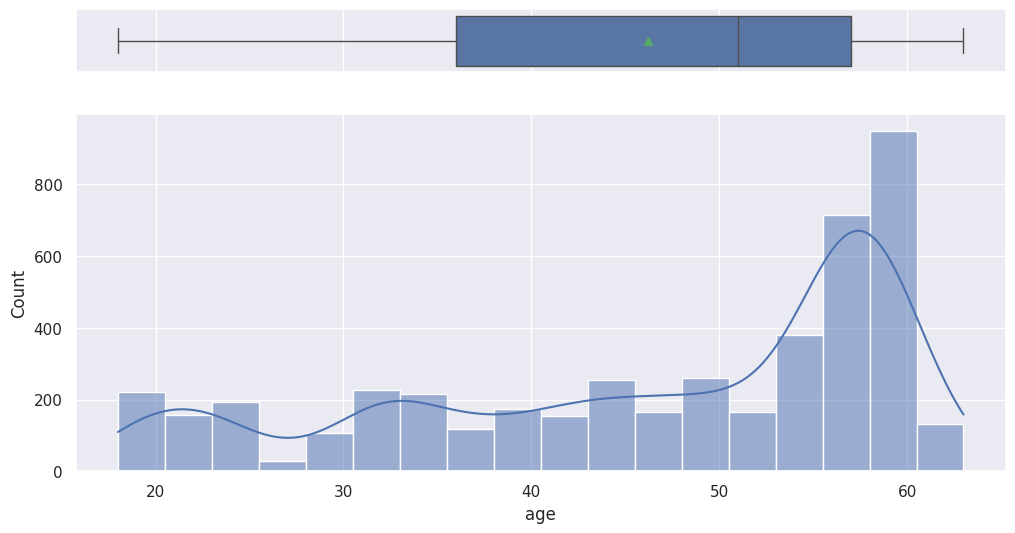

In [ ]:
hist_plot(df, 'age')

The graph skews to the left meaning that the average age of people on the site are older. This means that older leads might be converted to potential customers.

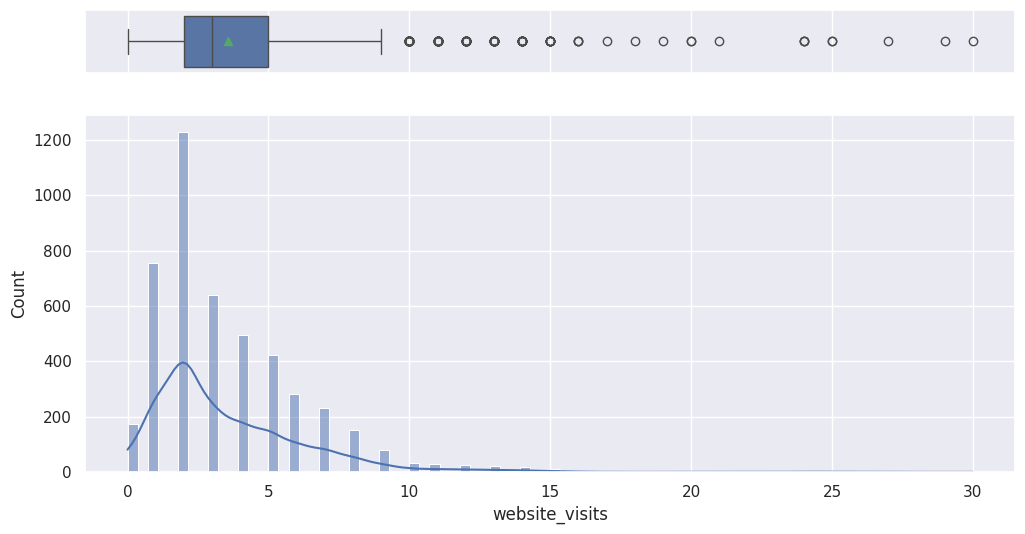

In [ ]:
hist_plot(df, 'website_visits')

Graph skews to the right, the majority of visits are within the 0 to 10 range.

In [ ]:
df[(df.website_visits <10)]

,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4606,58,Unemployed,Mobile App,High,7,210,3.598,Email Activity,No,No,No,No,No,0
4608,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0


In [ ]:
df.loc[df.website_visits > 10, 'website_visits'] = 10

Because there are so many outliers in this data set, we are performing a capping in order to prevent htem from disproportionaly affecting the model training set.

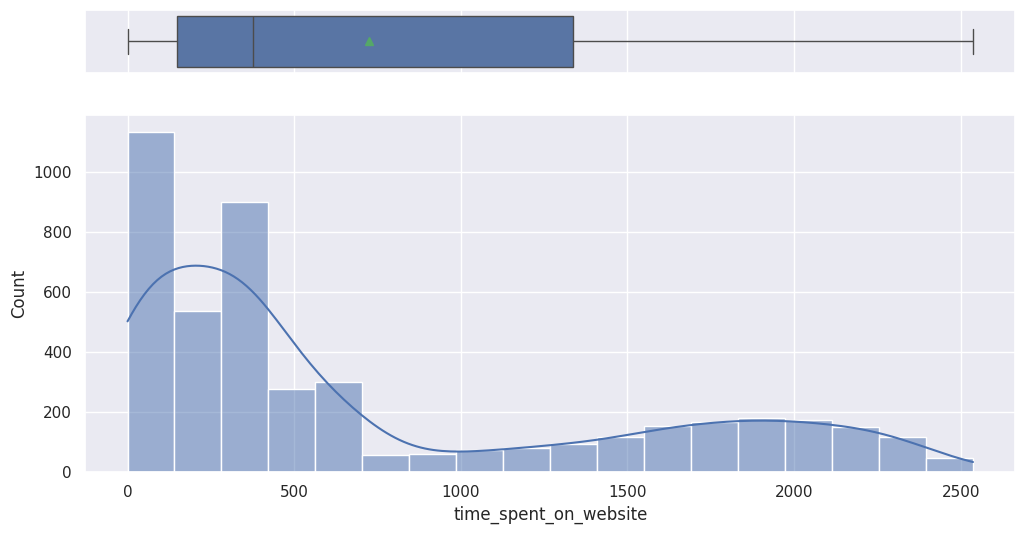

In [ ]:
hist_plot(df, 'time_spent_on_website')

The graph skews to the right.

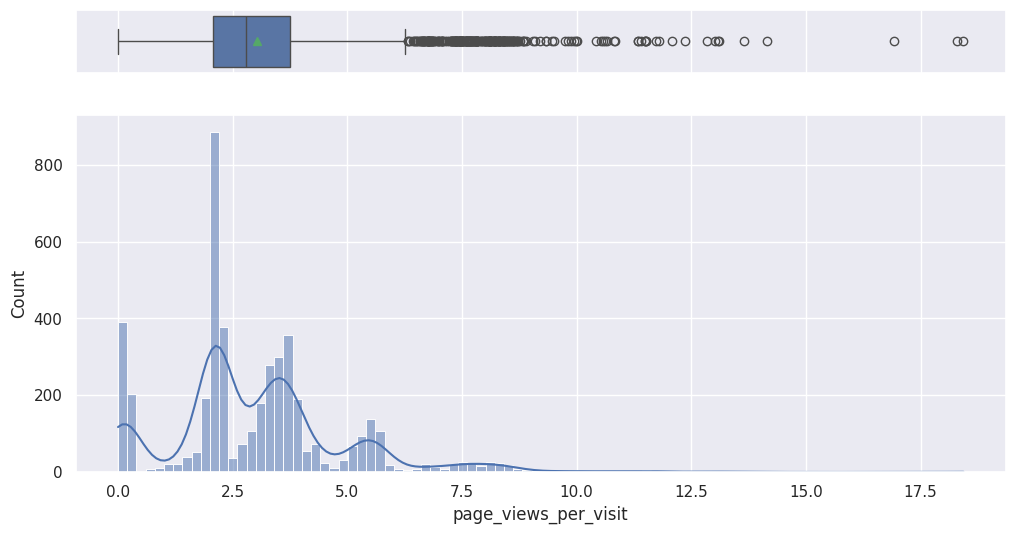

In [ ]:
hist_plot(df, 'page_views_per_visit')

In [ ]:
df[(df.page_views_per_visit> 7)]

,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0
32,58,Professional,Mobile App,High,10,1151,18.434,Phone Activity,No,No,No,Yes,No,0
47,35,Professional,Mobile App,Medium,2,497,7.050,Email Activity,No,No,No,No,No,0
110,31,Professional,Website,High,1,187,7.364,Email Activity,No,No,No,Yes,No,1
125,59,Unemployed,Mobile App,Medium,2,246,7.662,Phone Activity,No,No,No,Yes,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4433,47,Unemployed,Mobile App,Medium,7,646,7.303,Website Activity,No,No,No,No,No,0
4466,58,Professional,Website,Medium,2,1691,9.200,Email Activity,No,Yes,No,No,No,1
4514,42,Professional,Mobile App,Medium,2,762,7.997,Phone Activity,No,No,No,No,No,0
4572,55,Unemployed,Mobile App,High,1,617,7.397,Phone Activity,No,No,No,No,No,0


In [ ]:
df.loc[df.page_views_per_visit > 7, 'page_views_per_visit'] = 7

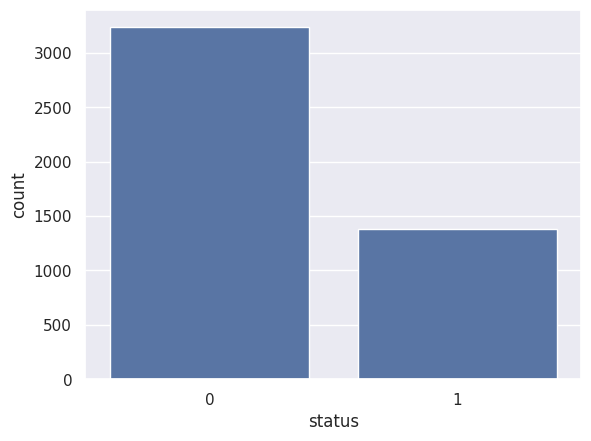

In [ ]:
sns.countplot(x = df ['status'])
plt.show()

In [ ]:
df['status'].value_counts(normalize= True)

,proportion
status,
0,0.701431
1,0.298569


There are more people who are not converted status leads than there are converted. 70% of people are unconverted

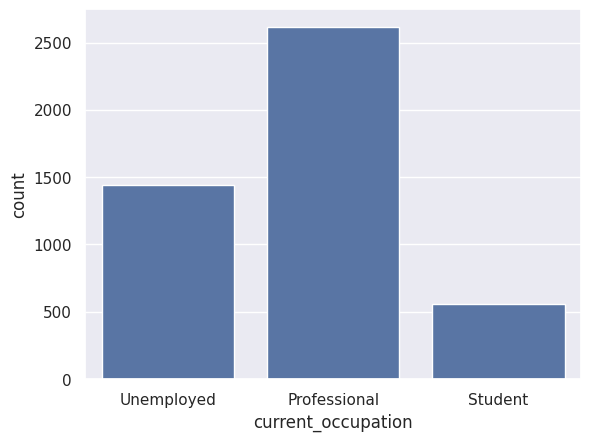

In [ ]:
sns.countplot(x = df ['current_occupation'])
plt.show()

In [ ]:
df['current_occupation'].value_counts(normalize= True)

,proportion
current_occupation,
Professional,0.567216
Unemployed,0.312446
Student,0.120338


56 percent of the people are professionals. 31% are unemployed and 12% are students. This means most of our population are professionals and unemployed people.

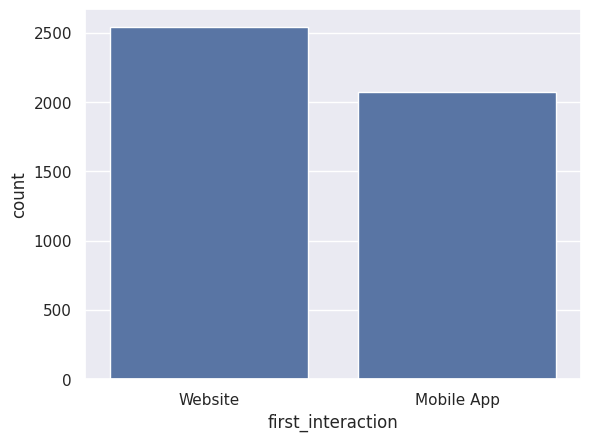

In [ ]:
sns.countplot(x = df ['first_interaction'])
plt.show()


In [ ]:
df['first_interaction'].value_counts(normalize= True)

,proportion
first_interaction,
Website,0.551171
Mobile App,0.448829


The percentages of people who first interacted with the site are almost equal with people on the website squeaking out a slight majority.


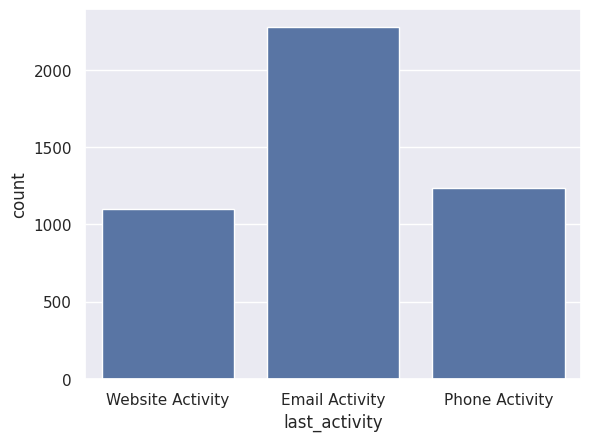

In [ ]:
sns.countplot( x = df ['last_activity'])
plt.show()

In [ ]:
df['last_activity'].value_counts(normalize= True)

,proportion
last_activity,
Email Activity,0.493929
Phone Activity,0.267563
Website Activity,0.238508


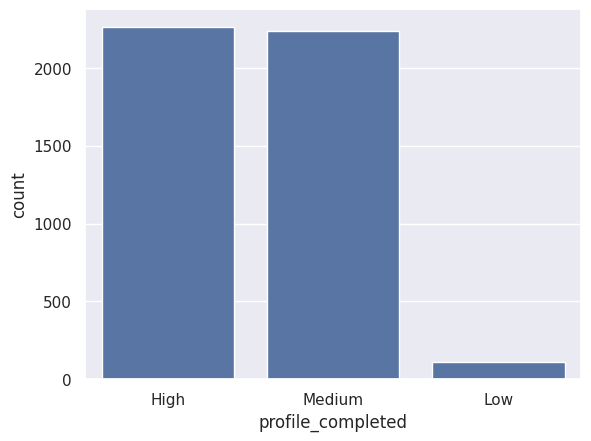

In [ ]:
sns.countplot(x = df ['profile_completed'])
plt.show()

In [ ]:
df['profile_completed'].value_counts(normalize= True)

,proportion
profile_completed,
High,0.490893
Medium,0.485906
Low,0.023200


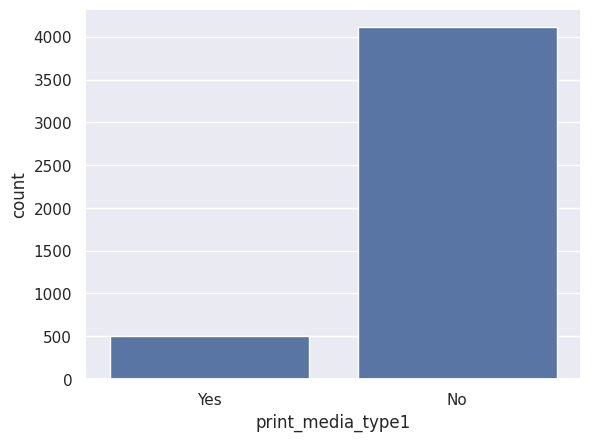

In [ ]:
sns.countplot(x = df ['print_media_type1'])
plt.show()

In [ ]:
df['print_media_type1'].value_counts(normalize= True)

,proportion
print_media_type1,
No,0.892238
Yes,0.107762


Now it is time for Bivariate Data Analysis

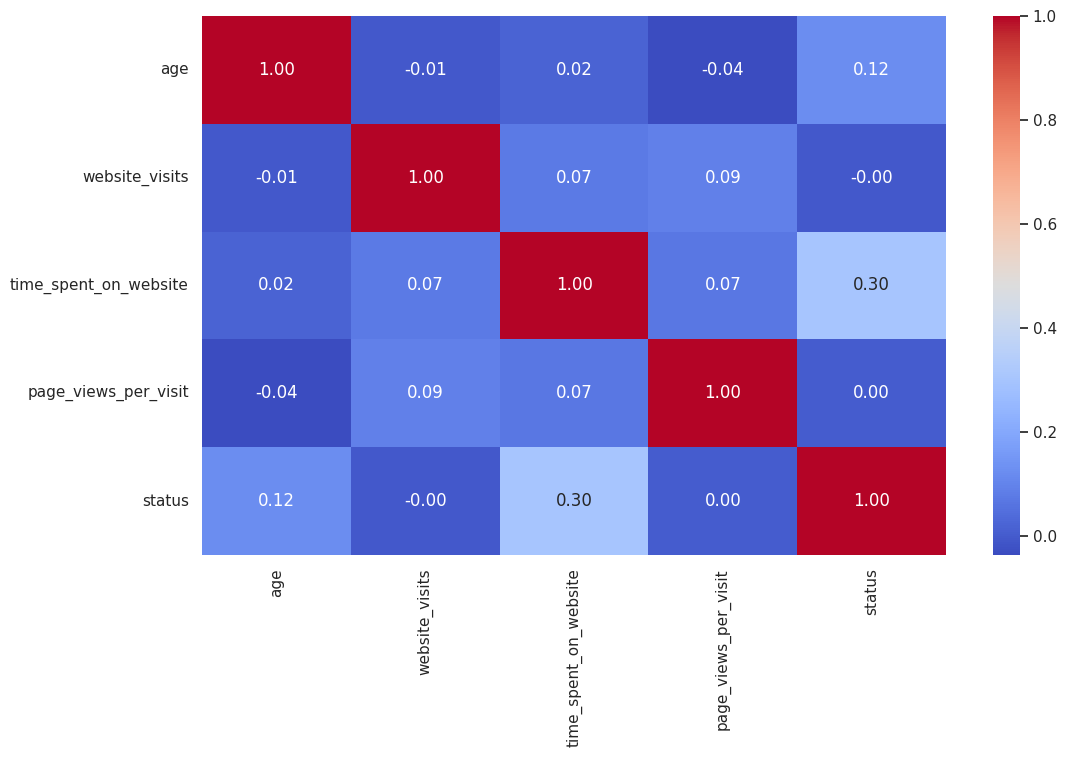

In [ ]:
cols_list = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 7))
sns.heatmap(df[cols_list].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

It seems that based on the data none of the values are strongly correlative to each other except for time spent on website and status of person.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

In [ ]:
#Defining the stacked barplot() function

def stacked_barplot(data,predictor,target,figsize = (10,6)):
  (pd.crosstab(data[predictor],data[target],normalize='index')*100).plot(kind='bar',figsize=figsize,stacked=True)
  plt.legend(loc="lower right")
  plt.ylabel(target)

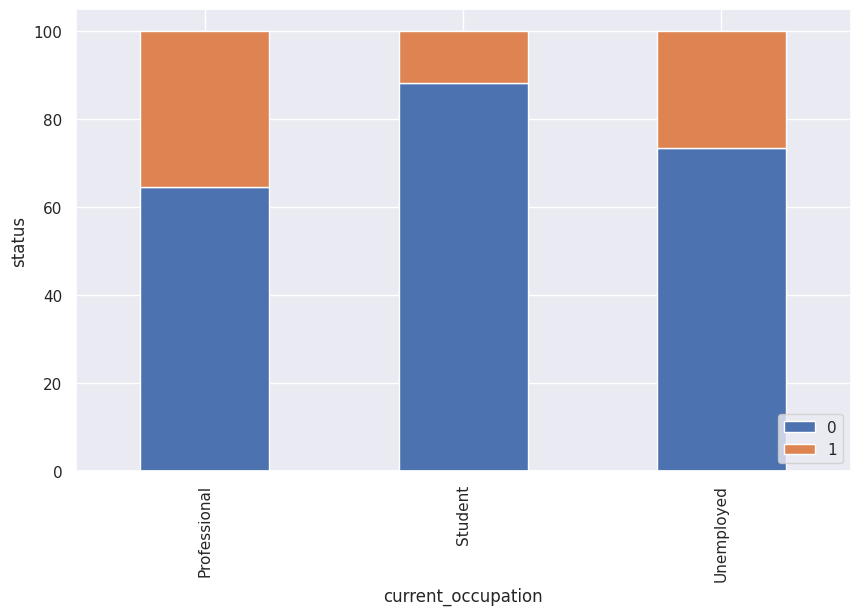

In [ ]:
stacked_barplot(df,'current_occupation','status')

This answers question one There is definitely a correlation between current occupation of users and status. Those who are students have a higher rate of conversion than professionals and unemployed. And unemployed people have a higher conversion rate than professionals. Although all of them are above 60% conversion.

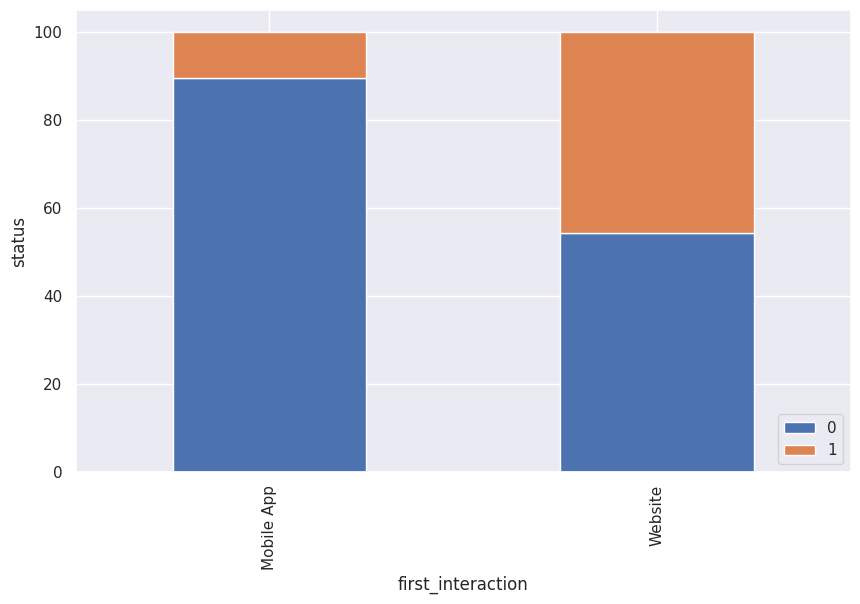

In [ ]:
stacked_barplot(df,'first_interaction','status')


In [ ]:
conversion_rates_by_first_interaction = df.groupby('first_interaction')['status'].mean() * 100
print('Conversion Rates by First Interaction:')
print(conversion_rates_by_first_interaction)

Conversion Rates by First Interaction:
first_interaction
Mobile App    10.531401
Website       45.594020
Name: status, dtype: float64


This graph answers question two, this plot shows that using the website leads to a higher conversion rate over a mobile  app. The mobile app is almost at 10% conversion rate whereas the website is at 50%

For question 3  phone activity has the highest conversion rate with email activity being in second place and website in a close third.

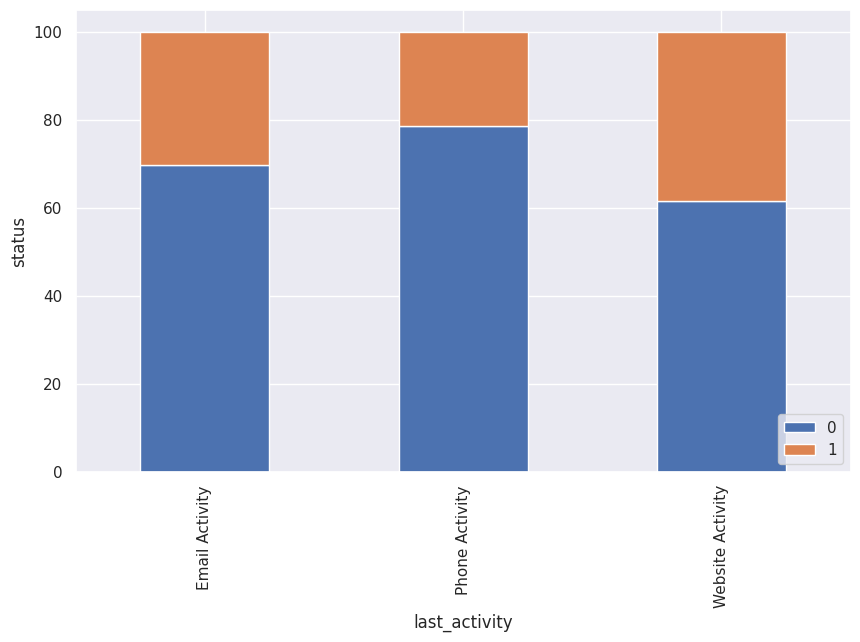

In [ ]:
stacked_barplot(df, 'last_activity', 'status')

In [ ]:
conversion_rates_by_last_activity = df.groupby('last_activity')['status'].mean() * 100
print('Conversion Rates by Last Activity:')
print(conversion_rates_by_last_activity)

Conversion Rates by Last Activity:
last_activity
Email Activity      30.333626
Phone Activity      21.312804
Website Activity    38.454545
Name: status, dtype: float64


FOr Question 3 conversion rate website activity is at 38% whcih is the highest compared to phone and email activity. This means that the website interactions work best.

Question 4: Which of these channels have the highest lead conversion rate

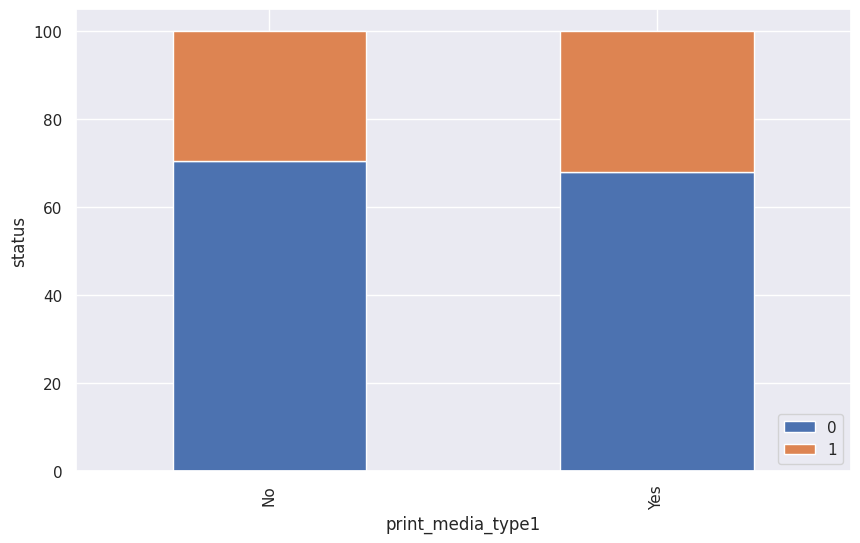

In [ ]:
stacked_barplot(df,'print_media_type1','status')

In [ ]:
print_media_type1_leads = df[df['print_media_type1'] == 'Yes']

conversion_rate_print_media_type1 = print_media_type1_leads['status'].mean() * 100

print(f"Conversion rate for leads from 'print_media_type1': {conversion_rate_print_media_type1:.2f}%")

Conversion rate for leads from 'print_media_type1': 31.99%


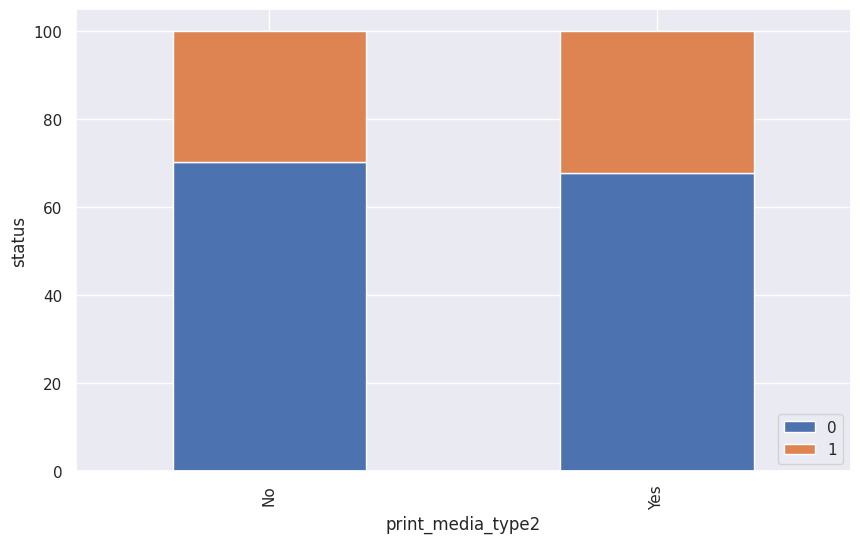

In [ ]:
stacked_barplot(df, 'print_media_type2', 'status')

In [ ]:
print_media_type2_leads = df[df['print_media_type2'] == 'Yes']

conversion_rate_print_media_type2 = print_media_type2_leads['status'].mean() * 100

print(f"Conversion rate for leads from 'print_media_type2': {conversion_rate_print_media_type2:.2f}%")

Conversion rate for leads from 'print_media_type2': 32.19%


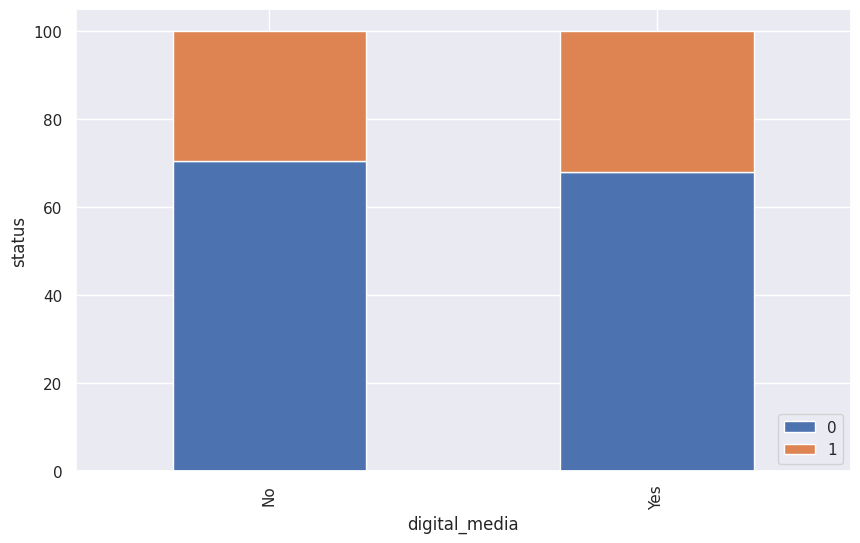

In [ ]:
stacked_barplot(df,'digital_media','status')

In [ ]:
# Filter for leads who came through a digital media
digital_media_leads = df[df['digital_media'] == 'Yes']

# Calculate the conversion rate for referral leads
conversion_rate_digital = digital_media_leads['status'].mean() * 100

print(f"Conversion rate for leads from 'digital media': {conversion_rate_digital:.2f}%")

Conversion rate for leads from 'digital media': 31.88%


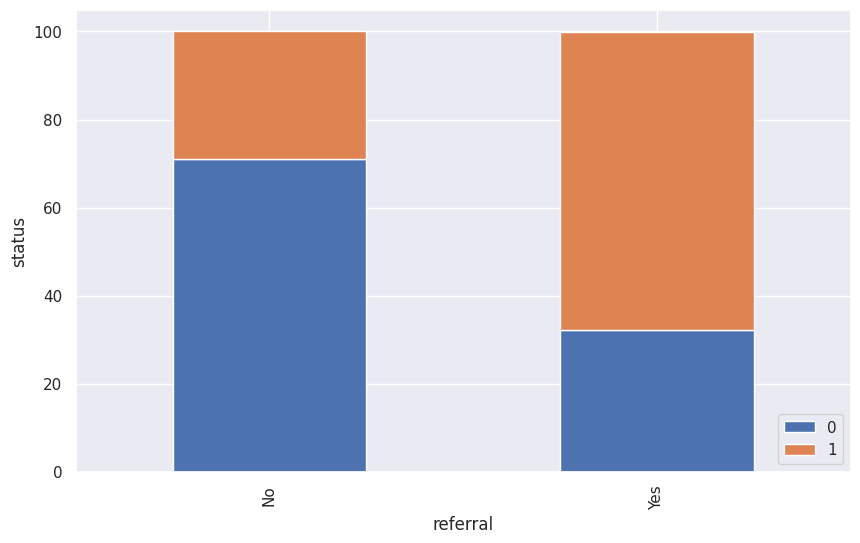

In [ ]:
stacked_barplot(df,'referral', 'status')

In [ ]:
#filter leads coming through referrals

referral_leads = df[df['referral'] == 'Yes']

# Calculate the conversion rate for referral leads
conversion_rate_referral= referral_leads['status'].mean() * 100

print(f"Conversion rate for leads from 'digital media': {conversion_rate_referral:.2f}%")

Conversion rate for leads from 'digital media': 67.74%


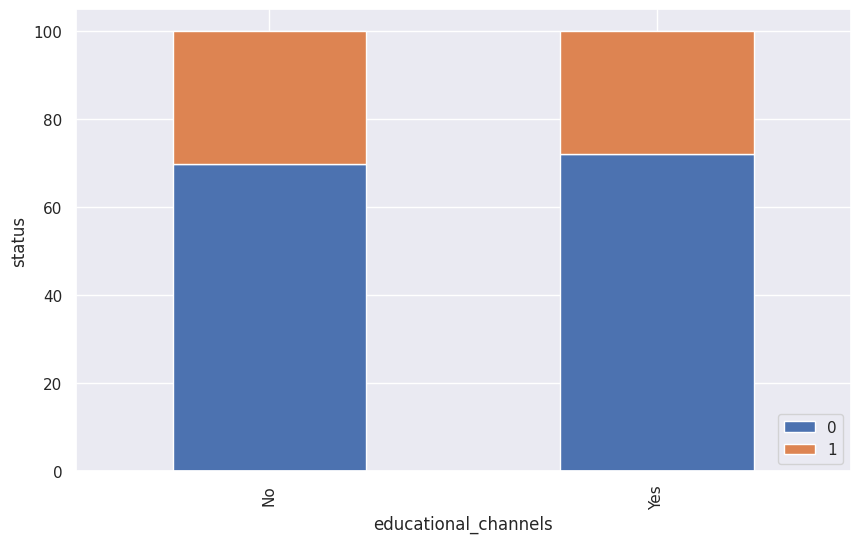

In [ ]:
stacked_barplot(df, 'educational_channels', 'status')

In [ ]:
educational_leads = df[df['educational_channels'] == 'Yes']

conversion_rate_educational = educational_leads['status'].mean() * 100

print(f"Conversion rate for leads from 'educational channels': {conversion_rate_educational:.2f}%")

Conversion rate for leads from 'educational channels': 27.94%


Among all of the barplots the referrals are teh highest conversion rates 67%.

In order to do data processing we are going to have to seperate the variables (features) from the dependent variables. In this case the 'status" column and the rest of our independent variables.


In [ ]:
#seperate the target variables 'status' into y
y= df['status']
#drop the "status" column from the data frame to get the features (X)
x= df.drop('status', axis = 1)

print("Features (X) head:")
display(x.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral
0,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No
1,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No
2,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No
3,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No
4,23,Student,Website,High,4,600,7.000,Email Activity,No,No,No,No,No



Target (y) head:


,status
0,1
1,0
2,0
3,1
4,0


We do not need to drop anymore columns outside of 'ID" and Status column. All of these other features are determinative of making leads people likely to convert.

## Data Preprocessing

- Missing value treatment (if needed) (Don't need it)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.30,random_state=1,stratify = y)

In [ ]:
# Select categorical columns from x
categorical_cols = x.select_dtypes(include='object').columns

# Apply one-hot encoding
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True)

print("Shape of x after one-hot encoding:", x.shape)
print("First 5 rows of x after one-hot encoding:")
display(x.head())

Shape of x after one-hot encoding: (4612, 16)
First 5 rows of x after one-hot encoding:


,age,website_visits,time_spent_on_website,page_views_per_visit,current_occupation_Student,current_occupation_Unemployed,first_interaction_Website,profile_completed_Low,profile_completed_Medium,last_activity_Phone Activity,last_activity_Website Activity,print_media_type1_Yes,print_media_type2_Yes,digital_media_Yes,educational_channels_Yes,referral_Yes
0,57,7,1639,1.861,False,True,True,False,False,False,True,True,False,True,False,False
1,56,2,83,0.320,False,False,False,False,True,False,True,False,False,False,True,False
2,52,3,330,0.074,False,False,True,False,True,False,True,False,False,True,False,False
3,53,4,464,2.057,False,True,True,False,False,False,True,False,False,False,False,False
4,23,4,600,7.000,True,False,True,False,False,False,False,False,False,False,False,False


## Building a Decision Tree model

### Evaluating the Decision Tree Model

In [ ]:
model_dt = DecisionTreeClassifier()
model_dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
# Make predictions on the test set for evaluation
y_pred_dt = model_dt.predict(x_test)

# print the classification report
print ("Classification report for Decision Tree:\n", classification_report(y_test, y_pred_dt))

#print the confusion matrix
print("Confusion Report for Decision Tree:\n", confusion_matrix(y_test, y_pred_dt))

# Calculate and print ROC AUC score
roc_auc_dt = roc_auc_score(y_test, model_dt.predict_proba(x_test)[:, 1])
print(f"ROC AUC Score for Decision Tree: {roc_auc_dt:.4f}")

Classification report for Decision Tree:
               precision    recall  f1-score   support

           0       0.85      0.86      0.86       971
           1       0.67      0.65      0.66       413

    accuracy                           0.80      1384
   macro avg       0.76      0.76      0.76      1384
weighted avg       0.80      0.80      0.80      1384

Confusion Report for Decision Tree:
 [[835 136]
 [143 270]]
ROC AUC Score for Decision Tree: 0.7579


### Evaluating the Tuned Decision Tree Model

In [ ]:
# Make predictions on the test set
y_pred_dt = model_dt.predict(x_test)

# Print the classification report
print("Classification Report for Decision Tree:\n", classification_report(y_test, y_pred_dt))

# Print the confusion matrix
print("Confusion Matrix for Decision Tree:\n", confusion_matrix(y_test, y_pred_dt))

# Calculate and print ROC AUC score
roc_auc_dt = roc_auc_score(y_test, model_dt.predict_proba(x_test)[:, 1])
print(f"ROC AUC Score for Decision Tree: {roc_auc_dt:.4f}")

Classification Report for Decision Tree:
               precision    recall  f1-score   support

           0       0.85      0.86      0.86       971
           1       0.67      0.65      0.66       413

    accuracy                           0.80      1384
   macro avg       0.76      0.76      0.76      1384
weighted avg       0.80      0.80      0.80      1384

Confusion Matrix for Decision Tree:
 [[835 136]
 [143 270]]
ROC AUC Score for Decision Tree: 0.7579


## Do we need to prune the tree?

It seems as though we have an 80% accuracy and an ROC AUC score of .7579 for the training and test data. But it will still be helpful to put parameters and prune the tree just so we can reduce the chance of overfitting and generalize better to unseen data.

### Hyperparameter Tuning for Decision Tree (Pruning)

In [ ]:
# Create the parameter grid
param_grid = {
    'max_depth': np.arange(2, 15, 1),
    'min_samples_leaf': np.arange(5, 50, 5),
    'min_samples_split': np.arange(10, 80, 10),
    'criterion': ['gini', 'entropy']
}

# Instantiate the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=1)

# Instantiate GridSearchCV
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(x_train, y_train)

# Get the best parameters and best score
best_params_dt = grid_search.best_params_
best_score_dt = grid_search.best_score_

print(f"Best Hyperparameters for Decision Tree: {best_params_dt}")
print(f"Best ROC AUC Score for Decision Tree from Grid Search: {best_score_dt:.4f}")

Fitting 5 folds for each of 1638 candidates, totalling 8190 fits
Best Hyperparameters for Decision Tree: {'criterion': 'entropy', 'max_depth': np.int64(6), 'min_samples_leaf': np.int64(40), 'min_samples_split': np.int64(10)}
Best ROC AUC Score from Grid Search: 0.9217


In [ ]:
# Instantiate the Decision Tree Classifier with the best parameters
tuned_dt_model = DecisionTreeClassifier(**best_params_dt, random_state=1)

# Fit the model on the training data
tuned_dt_model.fit(x_train, y_train)

# Make predictions on the test set
y_pred_tuned_dt = tuned_dt_model.predict(x_test)

# Print the classification report
print("Classification Report for Tuned Decision Tree:\n", classification_report(y_test, y_pred_tuned_dt))

# Print the confusion matrix
print("Confusion Matrix for Tuned Decision Tree:\n", confusion_matrix(y_test, y_pred_tuned_dt))

# Calculate and print ROC AUC score
roc_auc_tuned_dt = roc_auc_score(y_test, tuned_dt_model.predict_proba(x_test)[:, 1])
print(f"ROC AUC Score for Tuned Decision Tree: {roc_auc_tuned_dt:.4f}")

Classification Report for Tuned Decision Tree:
               precision    recall  f1-score   support

           0       0.88      0.90      0.89       971
           1       0.74      0.71      0.72       413

    accuracy                           0.84      1384
   macro avg       0.81      0.80      0.81      1384
weighted avg       0.84      0.84      0.84      1384

Confusion Matrix for Tuned Decision Tree:
 [[870 101]
 [121 292]]
ROC AUC Score for Tuned Decision Tree: 0.9077


Compared to the baseline model. This model does seem to be a marked improvement. The score for the test data is now 90% rather than 75%. This means this model will be able to grasp and understand unseen data and be able to understand who will be potential paying customers.


## Building a Random Forest model

In [ ]:
rf_model = RandomForestClassifier(random_state=1)
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=1)

In [ ]:
# Creating the Metric function
def metrics_score(actual, predicted):
  print(classification_report(actual, predicted))

  com = confusion_matrix(actual, predicted)
  plt.figure(figsize=(8,5))
  sns.heatmap(com, annot=True, fmt='.2f')
  plt.ylabel('Actual')
  plt.xlabel('Predicted')
  plt.show()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2264
           1       1.00      1.00      1.00       964

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



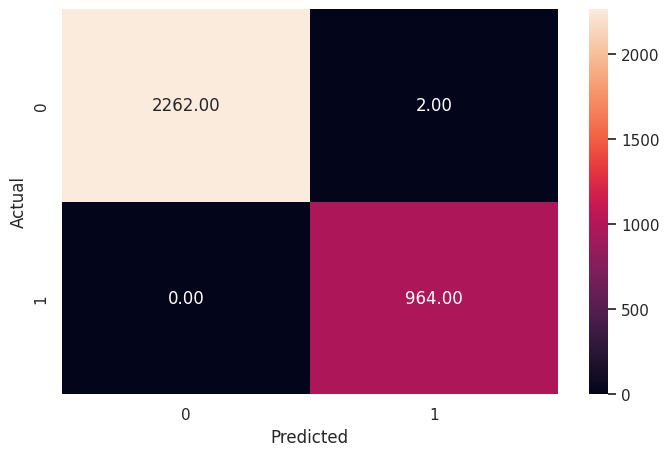

In [ ]:
y_pred_train_rf = rf_model.predict(x_train)
y_pred_test_rf = rf_model.predict(x_test)
metrics_score(y_train, y_pred_train_rf)

### Evaluating the Random Forest Model on Test Data

              precision    recall  f1-score   support

           0       0.89      0.92      0.90       971
           1       0.78      0.72      0.75       413

    accuracy                           0.86      1384
   macro avg       0.83      0.82      0.83      1384
weighted avg       0.86      0.86      0.86      1384



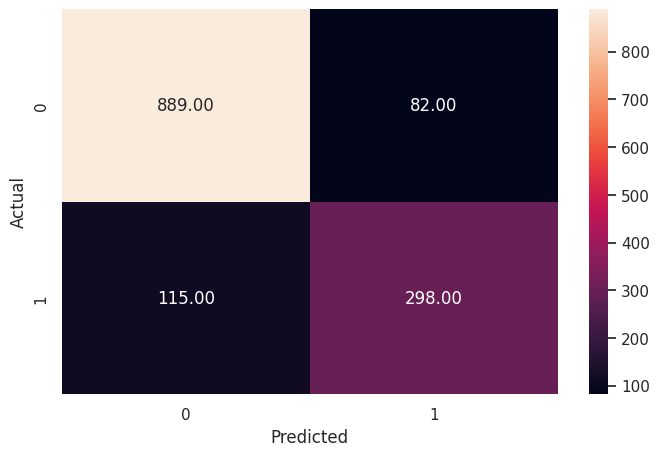

ROC AUC Score for Random Forest: 0.9122


In [ ]:
# Make predictions on the test set for Random Forest
y_pred_test_rf = rf_model.predict(x_test)

# Get metrics for the Random Forest Test data
metrics_score(y_test, y_pred_test_rf)

# Calculate and print ROC AUC score for Random Forest Test data
roc_auc_rf = roc_auc_score(y_test, rf_model.predict_proba(x_test)[:, 1])
print(f"ROC AUC Score for Random Forest: {roc_auc_rf:.4f}")

The random forest has a higher accuracy (.86 vs 0.84) and a better AUC score (.9122 vs 0.9077). Its superior for distinguishing between converted and non-converted leads. For predicting conversion leads the Random Forest shwos better precision (.78 vs .74) meaning when it it predicts a conversion it is more often correct. It also has a slightly highe rrecall .72 vs .71 meaning it identifies a slightly higher proprotion of the converted leads.

Given all of these the random forest model appears to be a stronger model for this classification task.


## Actionable Insights and Recommendations

4 insights:

1. Based on the insights we should prioritize Referrals Heavily. Leads acquired through referrals showed a higher conversion rate than others. Extralearn should invest ins trategies to encourage existing students/professionals to rrefer new leads through an incentive program.

2. We should also optimize website experience. Leads whose first interaction is throught he website have a significantly higher conversion rate 45.59 percent compared to mobile app.

3. We should tailor outreach by occupation.  Professionals form the largest groups, students show the strongest conversion rates followed by unemployed individuals and then professionals.  Considering this we should focus on tailoring our message to upskilling and creating lifelong careers for students, and job prospects for unemployed individuals.

4. We should also reevaluate mobile app. This is because it has a low first interaction conversion rate. We need to investigate why that is. Maybe there is something about the design that is turning people off.